In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../")

from src.models.knn import KNN
from src.models.neural_network import NeuralNetwork
from src.evaluation.metrics import accuracy, precision, recall, f1_score, confusion_matrix
from src.preprocessing.pca import PCA

In [2]:
data_path = Path("../data/processed/dry_bean_processed.npz")

data = np.load(data_path, allow_pickle=True)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

classes = data["classes"]
features = data["features"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (10836, 16)
X_test : (2707, 16)
y_train: (10836,)
y_test : (2707,)


In [3]:
pca = PCA()
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

In [4]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

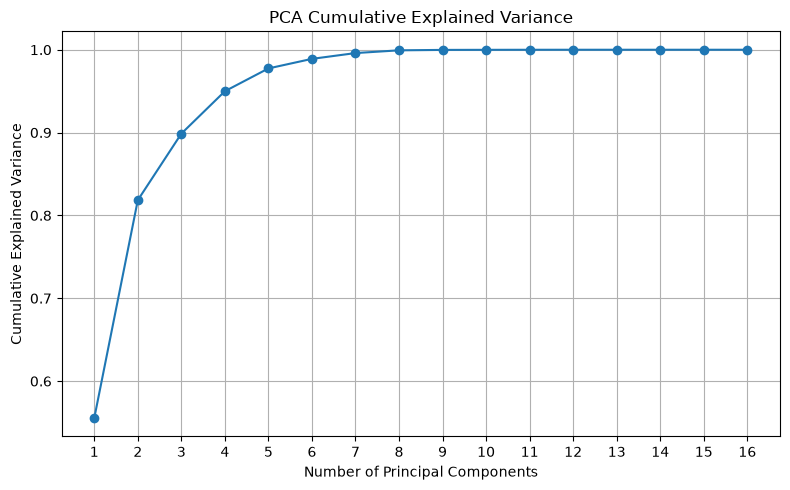

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid()

plt.tight_layout()
plt.show()

In [6]:
k_values = [2, 4, 6, 8, 10, 12, 14, 16]

In [7]:
pca_results = {}
pca_predictions = {}
pca_confusion_matrices = {}

In [8]:
for k in k_values:

    pca = PCA(n_components=k)

    pca.fit(X_train)

    X_train_pca = pca.transform(X_train)
    X_test_pca = pca.transform(X_test)

    knn = KNN(
        k=5,
        weights="uniform"
    )

    knn.fit(X_train_pca, y_train)

    y_pred = knn.predict(X_test_pca)

    model_name = f"KNN + PCA({k})"

    pca_results[model_name] = {
        "Accuracy": accuracy(y_test, y_pred),
        "Precision": precision(y_test, y_pred),
        "Recall": recall(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }

    pca_predictions[model_name] = y_pred

    pca_confusion_matrices[model_name] = confusion_matrix(
        y_test,
        y_pred
    )

In [9]:
pca_results_df = pd.DataFrame(pca_results).T
pca_results_df

,Accuracy,Precision,Recall,F1
KNN + PCA(2),0.859993,0.854555,0.851962,0.853106
KNN + PCA(4),0.888437,0.892038,0.887428,0.889034
KNN + PCA(6),0.926487,0.940418,0.937039,0.938658
KNN + PCA(8),0.925009,0.938876,0.935406,0.937091
KNN + PCA(10),0.925009,0.938876,0.935406,0.937091
KNN + PCA(12),0.925009,0.938876,0.935406,0.937091
KNN + PCA(14),0.925009,0.938876,0.935406,0.937091
KNN + PCA(16),0.925009,0.938876,0.935406,0.937091


In [10]:
for k in k_values:

    pca = PCA(n_components=k)

    pca.fit(X_train)

    X_train_pca = pca.transform(X_train)
    X_test_pca = pca.transform(X_test)

    nn = NeuralNetwork(
        layer_sizes=[k, 32, 16, 7],
        activation="relu",
        learning_rate=0.01,
        epochs=100,
        batch_size=32,
        dropout_rate=0.0,
        random_state=42
    )

    nn.fit(X_train_pca, y_train)

    y_pred = nn.predict(X_test_pca)

    model_name = f"Neural Network + PCA({k})"

    pca_results[model_name] = {
        "Accuracy": accuracy(y_test, y_pred),
        "Precision": precision(y_test, y_pred),
        "Recall": recall(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    }

    pca_predictions[model_name] = y_pred

    pca_confusion_matrices[model_name] = confusion_matrix(
        y_test,
        y_pred
    )

In [11]:
pca_results_df = pd.DataFrame(pca_results).T
pca_results_df.to_csv(
    "../experiments/comparison/pca_results.csv"
)
pca_results_df

,Accuracy,Precision,Recall,F1
KNN + PCA(2),0.859993,0.854555,0.851962,0.853106
KNN + PCA(4),0.888437,0.892038,0.887428,0.889034
KNN + PCA(6),0.926487,0.940418,0.937039,0.938658
KNN + PCA(8),0.925009,0.938876,0.935406,0.937091
KNN + PCA(10),0.925009,0.938876,0.935406,0.937091
KNN + PCA(12),0.925009,0.938876,0.935406,0.937091
KNN + PCA(14),0.925009,0.938876,0.935406,0.937091
KNN + PCA(16),0.925009,0.938876,0.935406,0.937091
Neural Network + PCA(2),0.865164,0.860399,0.857539,0.858443
Neural Network + PCA(4),0.897673,0.902797,0.896205,0.898614


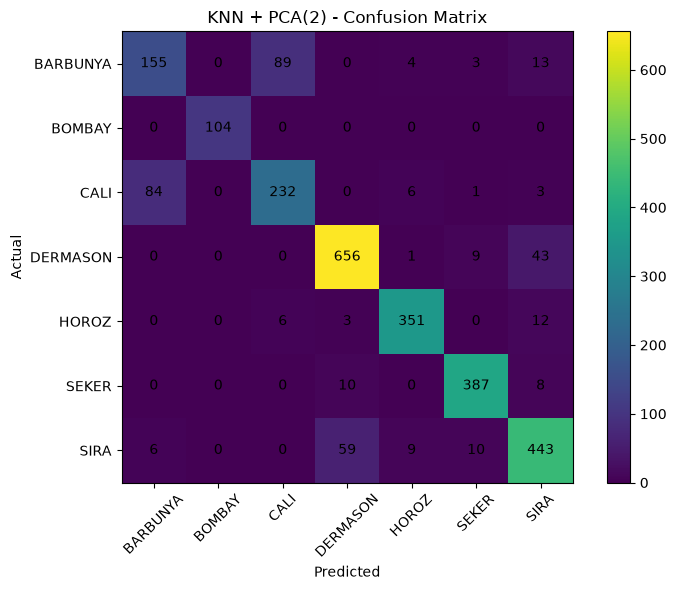

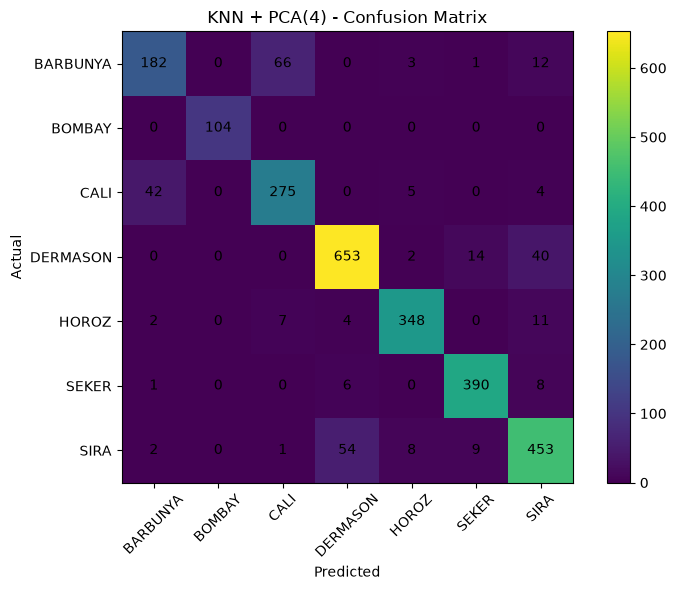

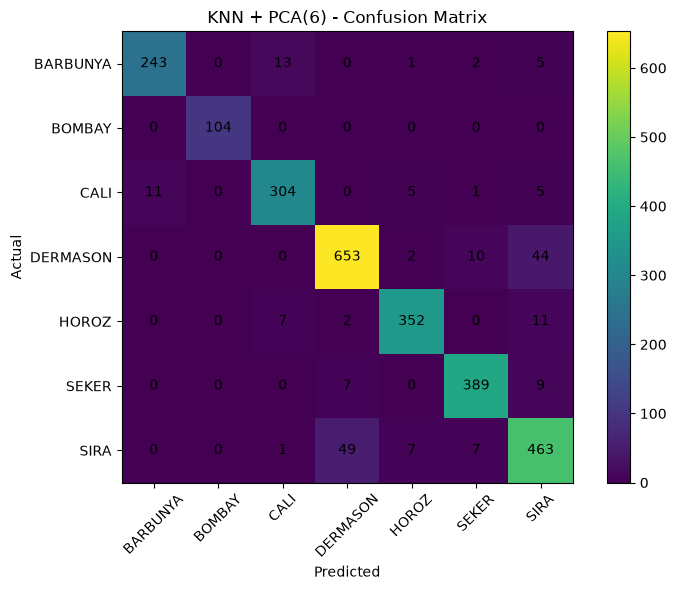

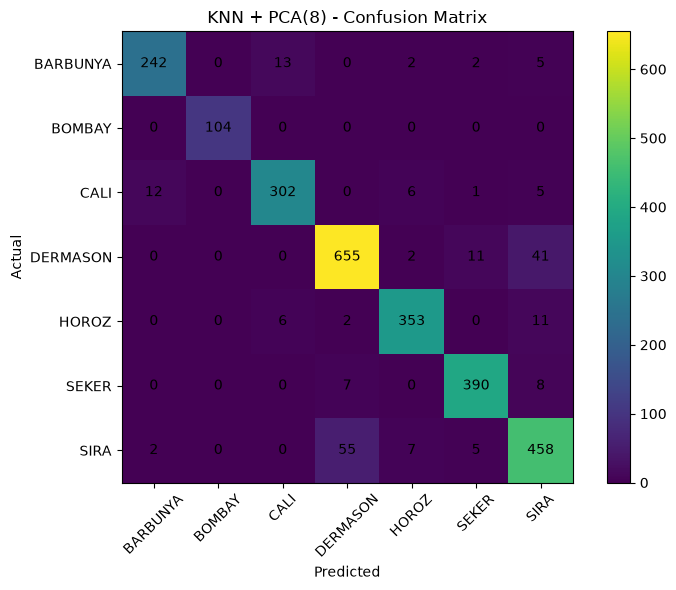

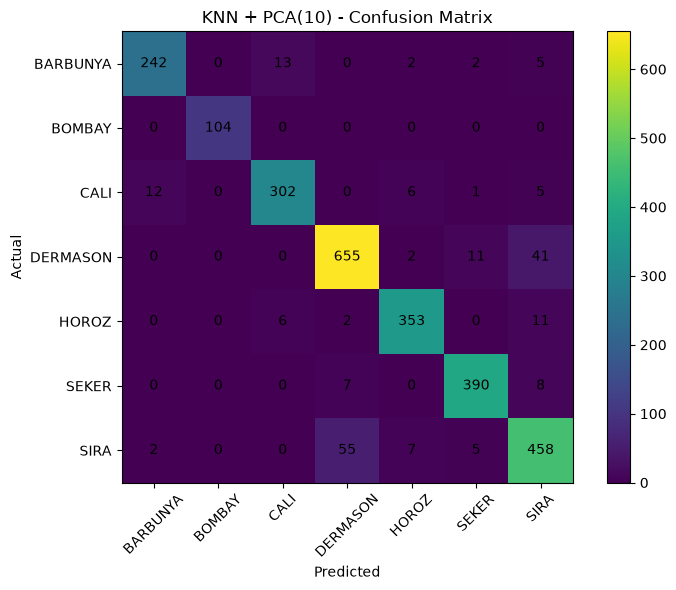

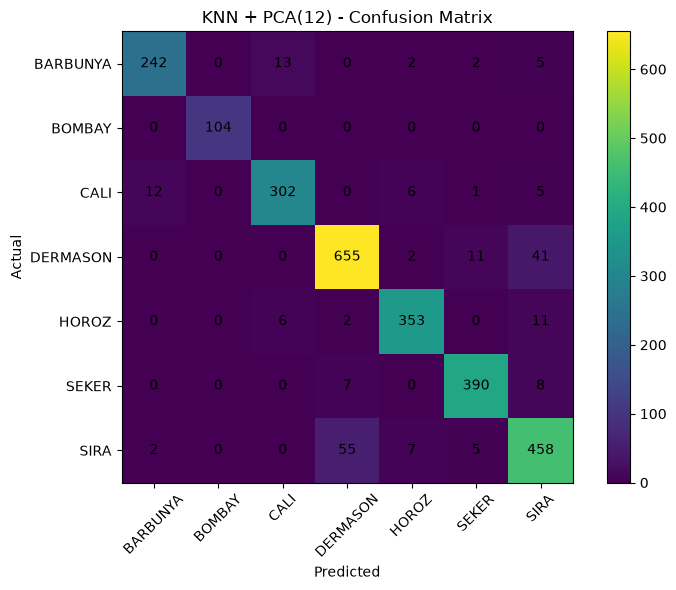

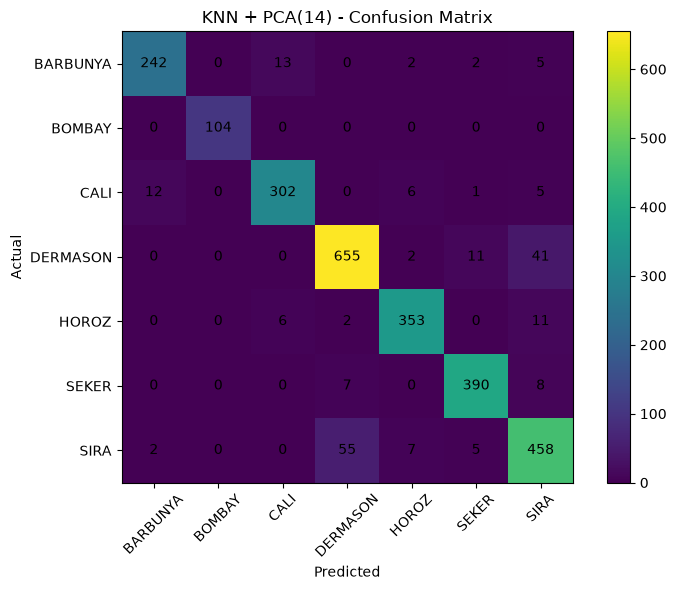

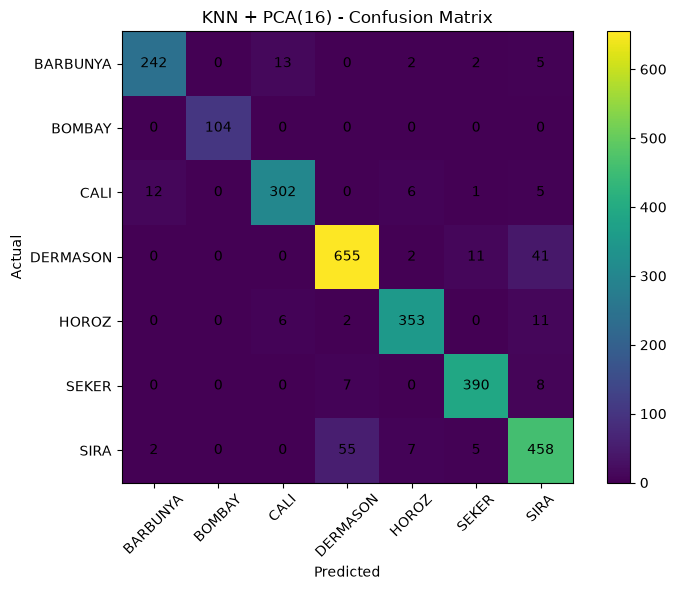

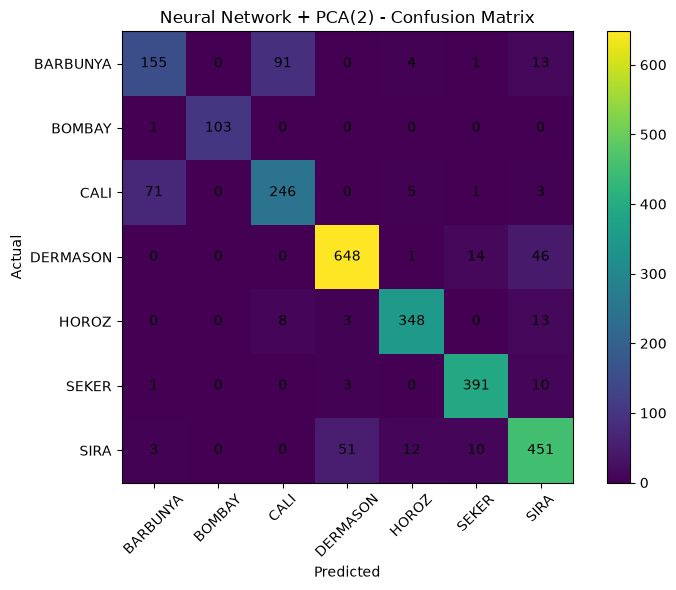

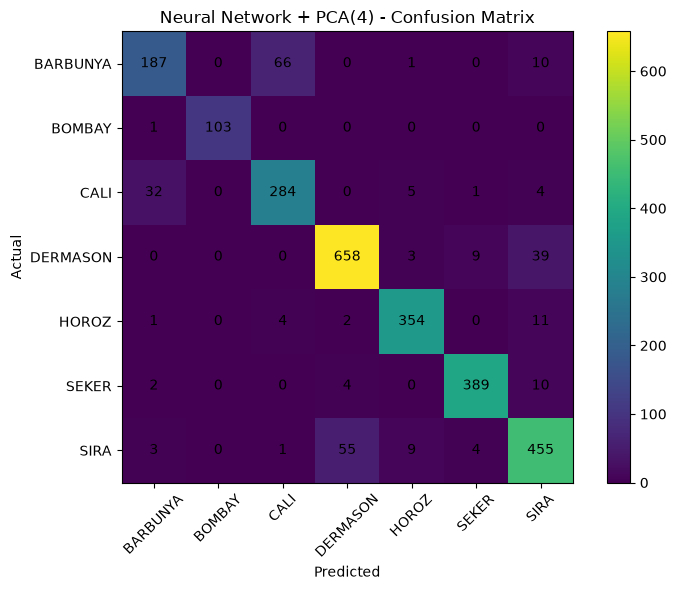

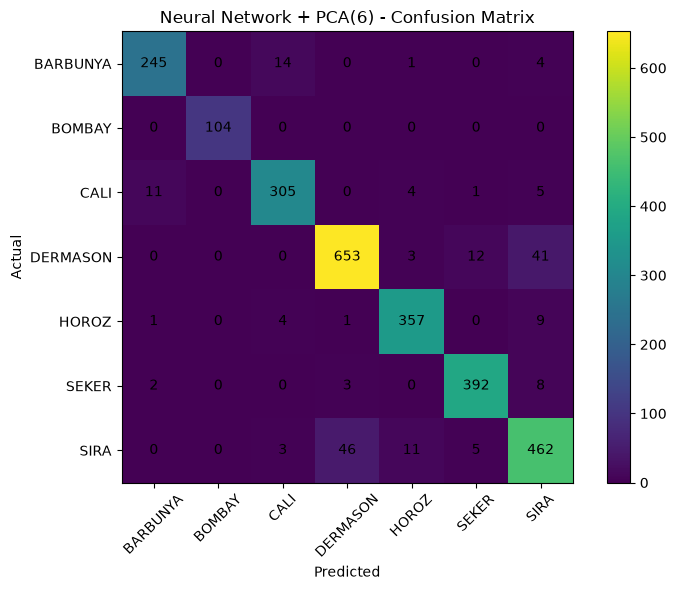

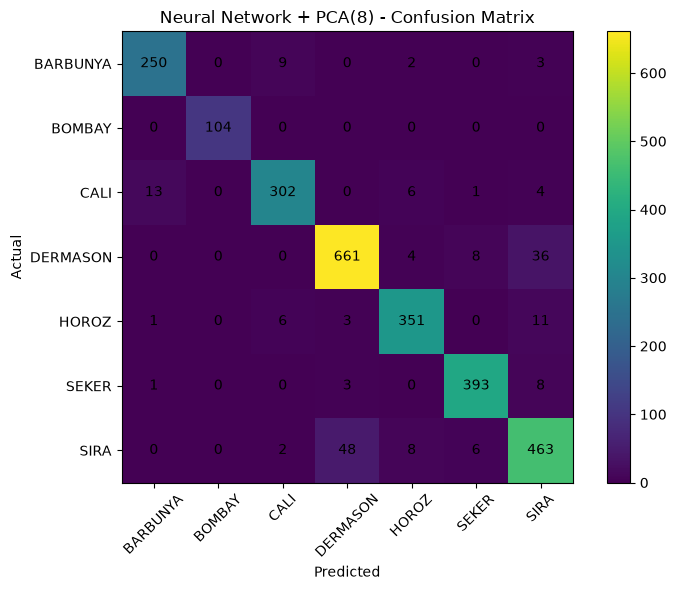

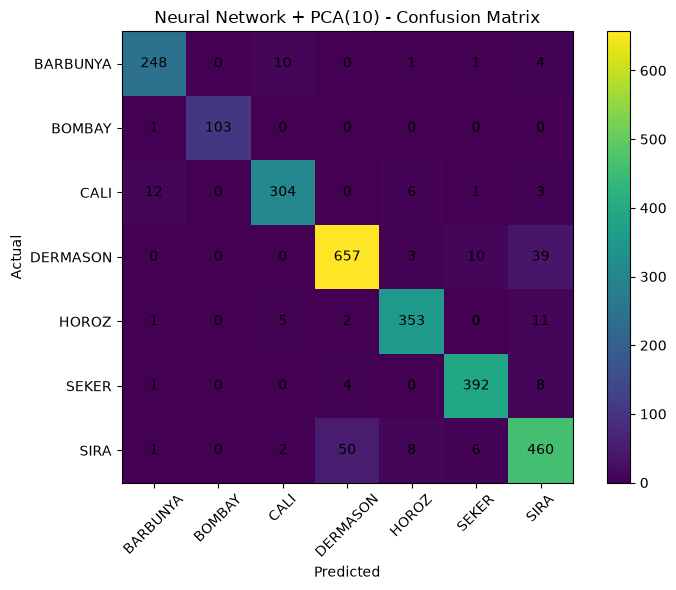

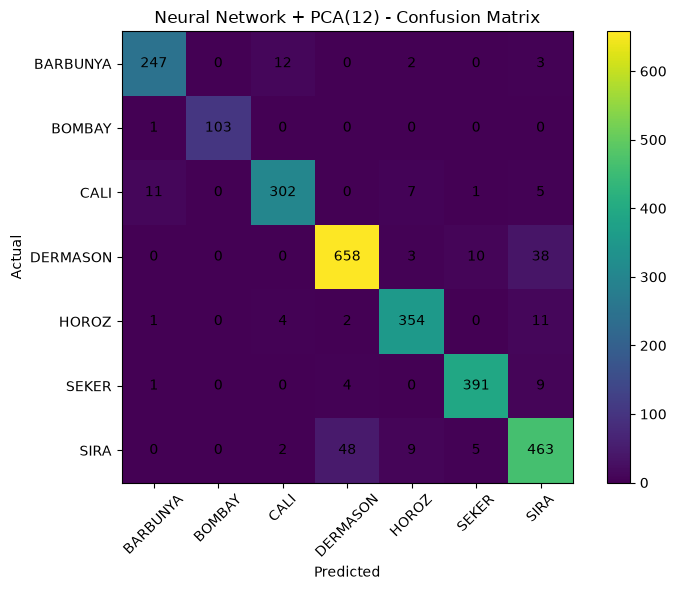

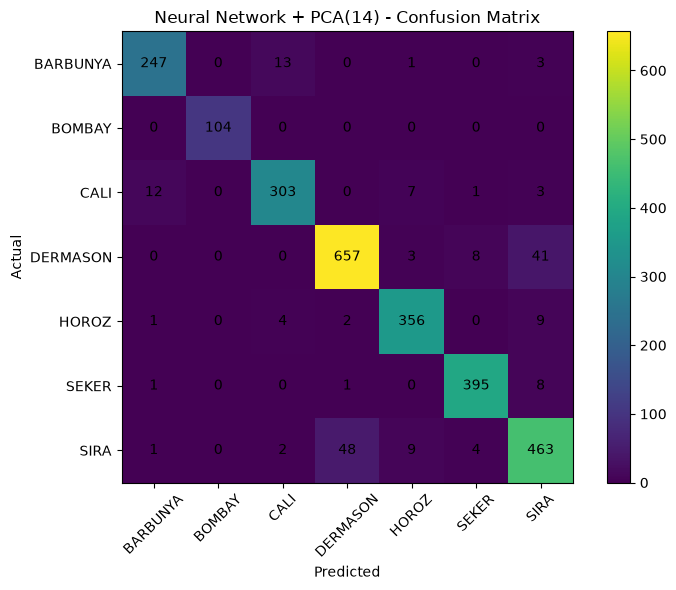

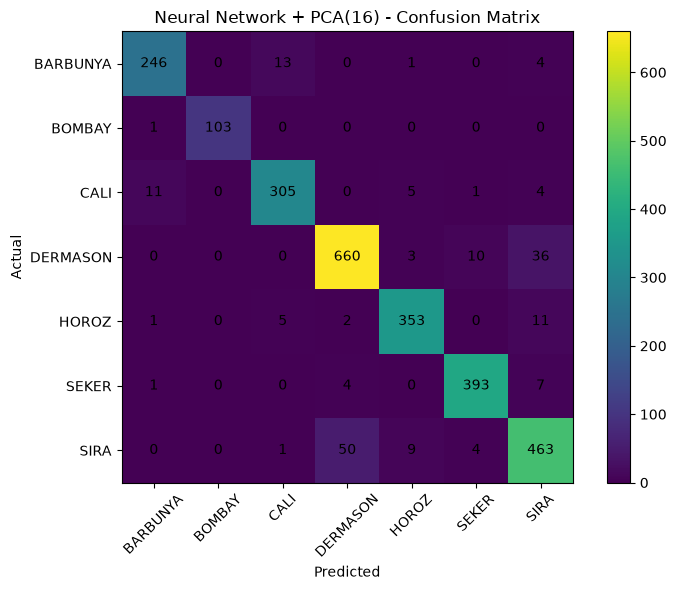

In [12]:
for model_name, cm in pca_confusion_matrices.items():
    plt.figure(figsize=(8, 6))

    plt.imshow(cm)

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks(
        range(len(classes)),
        classes,
        rotation=45
    )

    plt.yticks(
        range(len(classes)),
        classes
    )

    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()